# Evaluation of the ArgSum Systems


## Import packages


In [30]:
%load_ext autoreload
%autoreload 2
%env PYTORCH_ENABLE_MPS_FALLBACK=1
#######################
### Import packages ###
#######################
import json
import os
from itertools import product
from tqdm.notebook import tqdm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from argsum import (
    load_test_df,
    get_soft_scores,
    match_scorer_cov_eval,
    llm_cov_eval,
    llm_red_eval,
)
from transformers.utils import logging
logging.set_verbosity_error()

##########################
### Set plt parameters ###
##########################
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["mathtext.fontset"] = "custom"
plt.rcParams["mathtext.rm"] = "Times New Roman"
plt.rcParams["mathtext.it"] = "Times New Roman:italic"
plt.rcParams["mathtext.bf"] = "Times New Roman:bold"

#################
### Load data ###
#################
ArgKP21 = load_test_df("ArgKP21")
Debate_test = load_test_df("Debate_test")

#############################
### Define functions data ###
#############################

llm_cov_temp = 1
llm_red_temp = 1


def eval_classification_sum(
    df,
    classification_sums_dict,
    output_dir="investigations/4_automatic_evaluation",
    file_name=None,
):

    if "key_point" in df.columns:
        arg_sum_col = "key_point"
    elif "summary" in df.columns:
        arg_sum_col = "summary"

    topics = df["topic"].unique()
    stances = [str(stance) for stance in df["stance"].unique()]

    parameter_names = classification_sums_dict["parameter_names"]
    parameter_values = classification_sums_dict["parameter_values"]

    results = dict(
        zip(
            ["scores", "parameter_names", "parameter_values"],
            [
                dict(
                    zip(
                        topics,
                        [
                            dict(
                                zip(
                                    stances,
                                    [
                                        dict(
                                            zip(
                                                [
                                                    str(comb)
                                                    for comb in list(
                                                        product(*parameter_values)
                                                    )
                                                ],
                                                [
                                                    dict(
                                                        zip(
                                                            [
                                                                "bert_score_p",
                                                                "bart_score_parabank_rs",
                                                                "coverage_score",
                                                                "llm_coverage",
                                                                "llm_redundancy",
                                                                "runtime",
                                                            ],
                                                            [
                                                                None,
                                                                None,
                                                                None,
                                                                None,
                                                                None,
                                                                None,
                                                            ],
                                                        )
                                                    )
                                                    for i in range(
                                                        len(
                                                            list(
                                                                product(
                                                                    *parameter_values
                                                                )
                                                            )
                                                        )
                                                    )
                                                ],
                                            )
                                        )
                                        for i in range(len(stances))
                                    ],
                                )
                            )
                            for i in range(len(topics))
                        ],
                    )
                )
                for i in range(len(["scores"]))
            ]
            + [parameter_names, parameter_values],
        )
    )

    # device = torch.device("cpu")
    # match_scorer = torch.load(
    #     "models/match_scorer/cross_encoder/roberta_np/2024-Feb-20_08-20-28/best_model.pt",
    #     map_location=device,
    # ).to("cpu")

    # Iterate over topics and stances
    for topic_stance in tqdm(
        [(topic, stance) for topic in topics for stance in stances],
        leave=True,
        desc="topic + stance",
    ):

        topic = topic_stance[0]
        stance = topic_stance[1]

        refs_mask = (df["topic"] == topic) & (df["stance"] == int(stance))
        reference = df[refs_mask][arg_sum_col].unique()

        # Iterate over parameters
        for comb in tqdm(
            list(product(*parameter_values)), leave=True, desc="parameter"
        ):

            sums = list(
                classification_sums_dict["summaries"][str(comb)][topic][stance][
                    "sums"
                ].values()
            )
            # soft_scores = get_soft_scores(
            #     reference=reference,
            #     candidate=sums,
            #     similarity_functions=["bert_score_p", "bart_score_parabank_rs"],
            # )
            # coverage_score = match_scorer_cov_eval(
            #     reference=reference,
            #     candidate=sums,
            #     match_scorer=match_scorer,
            #     threshold=0.6,
            # )

            llm_cov_score = llm_cov_eval(
                reference=reference, candidate=sums, temperature=llm_cov_temp
            )
            llm_red_score = llm_red_eval(
                reference=reference, candidate=sums, temperature=llm_red_temp
            )

            # results["scores"][topic][stance][str(comb)]["bert_score_p"] = soft_scores[
            #     "bert_score_p"
            # ]["sR"]
            # results["scores"][topic][stance][str(comb)]["bart_score_parabank_rs"] = (
            #     soft_scores["bart_score_parabank_rs"]["sR"]
            # )
            # results["scores"][topic][stance][str(comb)][
            #     "coverage_score"
            # ] = coverage_score
            results["scores"][topic][stance][str(comb)]["llm_coverage"] = llm_cov_score
            results["scores"][topic][stance][str(comb)][
                "llm_redundancy"
            ] = llm_red_score
            results["scores"][topic][stance][str(comb)]["runtime"] = (
                classification_sums_dict["summaries"][str(comb)][topic][stance][
                    "runtime"
                ]
            )

    ########################
    ### Save results #######
    ########################

    if file_name != None:
        if not os.path.exists(output_dir):
            os.makedirs(output_dir)
        with open(output_dir + "/" + file_name, "w") as file:
            json.dump(results, file)

    return results


def get_best_classification_sum(file_names, dir, c_r=0.5):
    llm_coverage_system = []
    llm_redundancy_system = []
    llm_weighted_system = []
    runtime_system = []

    for file_name in file_names:

        with open(dir + "/" + file_name) as f:

            classification_sums_dict = json.load(f)
            topics = list(classification_sums_dict["scores"].keys())
            stances = list(classification_sums_dict["scores"][topics[0]].keys())
            params = list(
                classification_sums_dict["scores"][topics[0]][stances[0]].keys()
            )

            llm_weighted_top_sta = []
            llm_coverage_top_sta = []
            llm_redundancy_top_sta = []
            runtime_top_sta = []

            for topic in topics:
                for stance in stances:

                    llm_coverage = []
                    llm_redundancy = []
                    runtime = []

                    for param in params:

                        llm_coverage.append(
                            classification_sums_dict["scores"][topic][stance][param][
                                "llm_coverage"
                            ]
                        )
                        llm_redundancy.append(
                            classification_sums_dict["scores"][topic][stance][param][
                                "llm_redundancy"
                            ]
                        )
                        runtime.append(
                            classification_sums_dict["scores"][topic][stance][param][
                                "runtime"
                            ]
                        )

                    llm_weighted_top_sta.append(
                        max(
                            [
                                (c_r) * llm_coverage[i]
                                + (1 - c_r) * (1 - llm_redundancy[i])
                                for i in range(len(llm_coverage))
                            ]
                        )
                    )
                    idx = np.argmax(
                        [
                            (c_r) * llm_coverage[i]
                            + (1 - c_r) * (1 - llm_redundancy[i])
                            for i in range(len(llm_coverage))
                        ]
                    )

                    llm_coverage_top_sta.append(llm_coverage[idx])
                    llm_redundancy_top_sta.append(llm_redundancy[idx])
                    runtime_top_sta.append(runtime[idx])

            llm_weighted_system.append(llm_weighted_top_sta)
            llm_coverage_system.append(llm_coverage_top_sta)
            llm_redundancy_system.append(llm_redundancy_top_sta)
            runtime_system.append(runtime_top_sta)

    return llm_weighted_system


def eval_clustering_sum(
    df,
    clustering_sums_dict,
    output_dir="investigations/4_automatic_evaluation",
    file_name=None,
):

    if "key_point" in df.columns:
        arg_sum_col = "key_point"
    elif "summary" in df.columns:
        arg_sum_col = "summary"

    topics = df["topic"].unique()
    stances = [str(stance) for stance in df["stance"].unique()]
    parameter_names = clustering_sums_dict[
        "clu_parameter_values"
    ]  # Hier ist etwas schief gelaufen bei der Zuordnung
    parameter_values = clustering_sums_dict["sum_parameter_names"]

    results = dict(
        zip(
            ["scores", "parameter_names", "parameter_values"],
            [
                dict(
                    zip(
                        topics,
                        [
                            dict(
                                zip(
                                    stances,
                                    [
                                        dict(
                                            zip(
                                                [
                                                    str(comb)
                                                    for comb in list(
                                                        product(*parameter_values)
                                                    )
                                                ],
                                                [
                                                    dict(
                                                        zip(
                                                            [
                                                                "bert_score_p",
                                                                "bart_score_parabank_rs",
                                                                "coverage_score",
                                                                "llm_coverage",
                                                                "llm_redundancy",
                                                                "runtime",
                                                            ],
                                                            [
                                                                None,
                                                                None,
                                                                None,
                                                                None,
                                                                None,
                                                                None,
                                                            ],
                                                        )
                                                    )
                                                    for i in range(
                                                        len(
                                                            list(
                                                                product(
                                                                    *parameter_values
                                                                )
                                                            )
                                                        )
                                                    )
                                                ],
                                            )
                                        )
                                        for i in range(len(stances))
                                    ],
                                )
                            )
                            for i in range(len(topics))
                        ],
                    )
                )
                for i in range(len(["scores"]))
            ]
            + [parameter_names, parameter_values],
        )
    )
    # device = torch.device("cpu")
    # match_scorer = torch.load(
    #     "models/match_scorer/cross_encoder/roberta_np/2024-Feb-20_08-20-28/best_model.pt",
    #     map_location=device
    # )

    # Iterate over topics and stances
    for topic_stance in tqdm(
        [(topic, stance) for topic in topics for stance in stances],
        leave=True,
        desc="topic + stance",
    ):

        topic = topic_stance[0]
        stance = topic_stance[1]

        refs_mask = (df["topic"] == topic) & (df["stance"] == int(stance))
        reference = df[refs_mask][arg_sum_col].unique()


        # Iterate over parameters
        for comb in tqdm(
            list(product(*parameter_values)), leave=True, desc="parameter"
        ):

            sumss = clustering_sums_dict["summaries"][str(comb)][topic][stance]["()"][
                "sums"
            ]

 

            if sumss != None:
                try:
                    if type(list(sumss.values())[0]) == list:
                        sums = [sum[0] for sum in list(sumss.values())]
                    else:
                        sums = list(sumss.values())
                    # soft_scores = get_soft_scores(
                    #     reference=reference,
                    #     candidate=sums,
                    #     similarity_functions=["bert_score_p", "bart_score_parabank_rs"],
                    # )
                    # coverage_score = match_scorer_cov_eval(
                    #     reference=reference,
                    #     candidate=sums,
                    #     match_scorer=match_scorer,
                    #     threshold=0.6,
                    # )
                    llm_cov_score = llm_cov_eval(
                        reference=reference, candidate=sums, temperature=0.6
                    )
                    llm_red_score = llm_red_eval(
                        reference=reference, candidate=sums, temperature=0.5
                    )

                    # results["scores"][topic][stance][str(comb)]["bert_score_p"] = (
                    #     soft_scores["bert_score_p"]["sR"]
                    # )
                    # results["scores"][topic][stance][str(comb)][
                    #     "bart_score_parabank_rs"
                    # ] = soft_scores["bart_score_parabank_rs"]["sR"]
                    # results["scores"][topic][stance][str(comb)][
                    #     "coverage_score"
                    # ] = coverage_score
                    results["scores"][topic][stance][str(comb)][
                        "llm_coverage"
                    ] = llm_cov_score
                    results["scores"][topic][stance][str(comb)][
                        "llm_redundancy"
                    ] = llm_red_score
                    results["scores"][topic][stance][str(comb)]["runtime"] = (
                        clustering_sums_dict["summaries"][str(comb)][topic][stance][
                            "()"
                        ]["runtime"]
                    )
                except Exception as e:
                    del results["scores"][topic][stance][str(comb)]

            else:
                del results["scores"][topic][stance][str(comb)]

    ########################
    ### Save results #######
    ########################

    if file_name != None:
        if not os.path.exists(output_dir):
            os.makedirs(output_dir)
        with open(output_dir + "/" + file_name, "w") as file:
            json.dump(results, file)

    return results


def get_best_classification_sum(
    file_names,
    dir,
    c_r=(2 / 3),
    score_1="llm_coverage",
    score_2="llm_redundancy",
):
    llm_coverage_system = []
    llm_redundancy_system = []
    llm_weighted_system = []
    runtime_system = []

    for file_name in file_names:

        with open(dir + "/" + file_name) as f:

            classification_sums_dict = json.load(f)
            topics = list(classification_sums_dict["scores"].keys())
            stances = list(classification_sums_dict["scores"][topics[0]].keys())
            params = list(
                classification_sums_dict["scores"][topics[0]][stances[0]].keys()
            )

            llm_weighted_top_sta = []
            llm_coverage_top_sta = []
            llm_redundancy_top_sta = []
            runtime_top_sta = []

            for topic in topics:
                for stance in stances:

                    llm_coverage = []
                    llm_redundancy = []
                    runtime = []

                    for param in params:
                        try:
                            if (
                                classification_sums_dict["scores"][topic][stance][
                                    param
                                ][score_1]
                                != None
                            ) & (
                                classification_sums_dict["scores"][topic][stance][
                                    param
                                ][score_2]
                                != None
                            ):
                                llm_coverage.append(
                                    classification_sums_dict["scores"][topic][stance][
                                        param
                                    ][score_1]
                                )
                                llm_redundancy.append(
                                    classification_sums_dict["scores"][topic][stance][
                                        param
                                    ][score_2]
                                )
                                runtime.append(
                                    classification_sums_dict["scores"][topic][stance][
                                        param
                                    ]["runtime"]
                                )
                        except:
                            pass
                    llm_weighted_top_sta.append(
                        np.max(
                            [
                                (c_r) * llm_coverage[i]
                                + (1 - c_r) * (1 - llm_redundancy[i])
                                for i in range(len(llm_coverage))
                            ]
                        )
                    )
                    idx = np.argmax(
                        [
                            (c_r) * llm_coverage[i]
                            + (1 - c_r) * (1 - llm_redundancy[i])
                            for i in range(len(llm_coverage))
                        ]
                    )

                    llm_coverage_top_sta.append(llm_coverage[idx])
                    llm_redundancy_top_sta.append(llm_redundancy[idx])
                    runtime_top_sta.append(runtime[idx])

            llm_weighted_system.append(llm_weighted_top_sta)
            llm_coverage_system.append(llm_coverage_top_sta)
            llm_redundancy_system.append(llm_redundancy_top_sta)
            runtime_system.append(runtime_top_sta)

    return (
        llm_weighted_system,
        llm_coverage_system,
        llm_redundancy_system,
        runtime_system,
    )

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
env: PYTORCH_ENABLE_MPS_FALLBACK=1


## Classification-based Systems


In [ ]:
dir = "investigations/3_classification_summaries"
file_names = [
    "ArgKP21_BarH_Candidates.json",
    "ArgKP21_BarH_Key_Points.json",
    "ArgKP21_BarH.json",
    "ArgKP21_SMatchToPr_Candidates.json",
    "ArgKP21_SMatchToPr_Key_Points.json",
    "ArgKP21_SMatchToPr.json",
]

for file_name in file_names:
    with open(dir + "/" + file_name) as f:
        classification_sums_dict = json.load(f)
    if file_name[0] == "A":
        df = ArgKP21
    else:
        df = Debate_test

    results = eval_classification_sum(
        df=ArgKP21,
        classification_sums_dict=classification_sums_dict,
        file_name=file_name,
    )

In [ ]:
dir = "investigations/3_classification_summaries"
file_names = [
    "Debate_test_BarH_Candidates.json",
    "Debate_test_BarH_Key_Points.json",
    "Debate_test_BarH.json",
    "Debate_test_SMatchToPr_Candidates.json",
    "Debate_test_SMatchToPr_Key_Points.json",
    "Debate_test_SMatchToPr.json",
]

for file_name in file_names:
    with open(dir + "/" + file_name) as f:
        classification_sums_dict = json.load(f)
    if file_name[0] == "A":
        df = ArgKP21
    else:
        df = Debate_test

    results = eval_classification_sum(
        df=Debate_test,
        classification_sums_dict=classification_sums_dict,
        file_name=file_name,
    )

## Clustering-based Systems


In [ ]:
dir = "investigations/2_cluster_summaries"
file_names = [
    "ArgKP21_USKPM.json",
    "ArgKP21_MCArgSum_SBERT_all_mpnet_base_local.json",
    "ArgKP21_MCArgSum_SBERT_all_mpnet_base_global.json",
]

for file_name in file_names:
    with open(dir + "/" + file_name) as f:
        clustering_sums_dict = json.load(f)
    if file_name[0] == "A":
        df = ArgKP21
    else:
        df = Debate_test

    results = eval_clustering_sum(
        df=ArgKP21, clustering_sums_dict=clustering_sums_dict, file_name=file_name
    )

In [ ]:
dir = "investigations/2_cluster_summaries"
file_names = [
    "Debate_test_USKPM.json",
    "Debate_test_MCArgSum_SBERT_all_mpnet_base_local.json",
    "Debate_test_MCArgSum_SBERT_all_mpnet_base_global.json",
]
for file_name in file_names:
    with open(dir + "/" + file_name) as f:
        clustering_sums_dict = json.load(f)
    if file_name[0] == "A":
        df = ArgKP21
    else:
        df = Debate_test

    results = eval_clustering_sum(
        df=Debate_test, clustering_sums_dict=clustering_sums_dict, file_name=file_name
    )

## Results


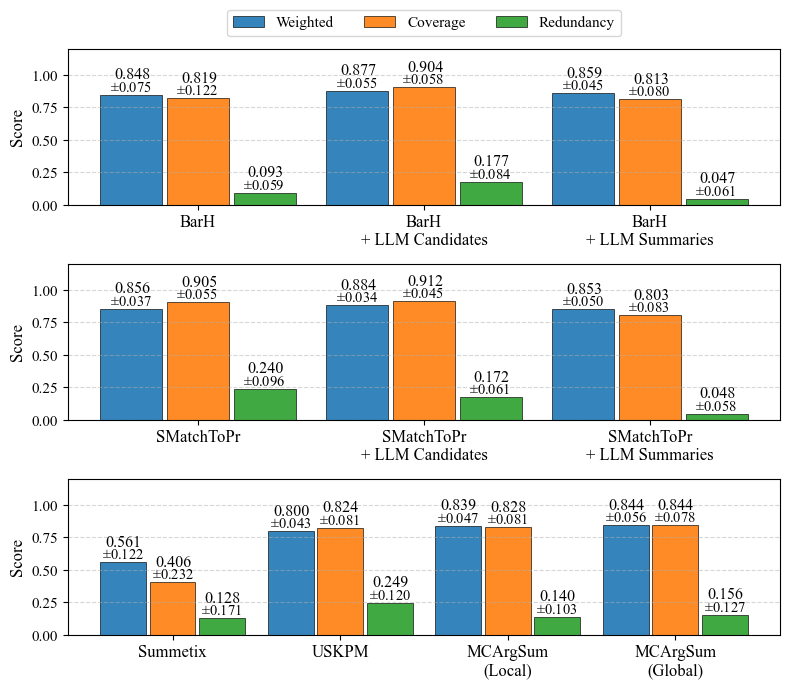

In [37]:
runtime_mean = []
runtime_std = []

c_r = 2 / 3
score_1 = "llm_coverage"
data = "ArgKP21"

dir = "investigations/4_automatic_evaluation"
file_names = ["_BarH.json", "_BarH_Candidates.json", "_BarH_Key_Points.json"]
file_names = [data + file_name for file_name in file_names]

x = ["BarH", "BarH\n+ LLM Candidates", "BarH\n+ LLM Summaries"]

cols = ["tab:blue", "tab:orange", "tab:green"]
x_ticks = [
    [0, 2 + 0.2, 4 + 0.4],
    [0.65, 2.65 + 0.2, 4.65 + 0.4],
    [1.3, 3.3 + 0.2, 5.3 + 0.4],
]

plt.figure(figsize=(8, 7))

plt.subplot(3, 1, 1)

llm_weighted_system, llm_coverage_system, llm_redundancy_system, runtime_system = (
    get_best_classification_sum(file_names, dir, c_r=c_r, score_1=score_1)
)
runtime_mean += np.mean(runtime_system, axis=1).tolist()
runtime_std += np.std(runtime_system, axis=1).tolist()

for i in range(0, 3):
    y = np.mean(llm_weighted_system, axis=1)[i]
    std = np.std(llm_weighted_system, axis=1)[i]
    if i == 0:
        bar = plt.bar(
            x=x_ticks[0][i],
            width=0.6,
            height=y,
            color=cols[0],
            edgecolor="black",
            linewidth=0.5,
            alpha=0.9,
            label="Weighted",
        )
    else:
        bar = plt.bar(
            x=x_ticks[0][i],
            width=0.6,
            height=y,
            color=cols[0],
            edgecolor="black",
            linewidth=0.5,
            alpha=0.9,
        )
    plt.text(
        x_ticks[0][i] - 0.155 - 0.01,
        y + 0.11 + 0.01,
        f"{np.round(y, 3)}00"[0:5],
        fontsize=11.5,
    )
    plt.text(
        x_ticks[0][i] - 0.2 - 0.01,
        y + 0.015 + 0.01,
        r"$\pm$" + f"{np.round(std, 3)}00"[0:5],
        fontsize=10.5,
    )

    y = np.mean(llm_coverage_system, axis=1)[i]
    std = np.std(llm_coverage_system, axis=1)[i]
    if i == 0:
        bar = plt.bar(
            x=x_ticks[1][i],
            width=0.6,
            height=y,
            color=cols[1],
            edgecolor="black",
            linewidth=0.5,
            alpha=0.9,
            label="Coverage",
        )
    else:
        bar = plt.bar(
            x=x_ticks[1][i],
            width=0.6,
            height=y,
            color=cols[1],
            edgecolor="black",
            linewidth=0.5,
            alpha=0.9,
        )
    plt.text(
        x_ticks[1][i] - 0.155 - 0.01,
        y + 0.11 + 0.01,
        f"{np.round(y, 3)}00"[0:5],
        fontsize=11.5,
    )
    plt.text(
        x_ticks[1][i] - 0.2 - 0.01,
        y + 0.015 + 0.01,
        r"$\pm$" + f"{np.round(std, 3)}00"[0:5],
        fontsize=10.5,
    )

    y = np.mean(llm_redundancy_system, axis=1)[i]
    std = np.std(llm_redundancy_system, axis=1)[i]
    if i == 0:
        bar = plt.bar(
            x=x_ticks[2][i],
            width=0.6,
            height=y,
            color=cols[2],
            edgecolor="black",
            linewidth=0.5,
            alpha=0.9,
            label="Redundancy",
        )
    else:
        bar = plt.bar(
            x=x_ticks[2][i],
            width=0.6,
            height=y,
            color=cols[2],
            edgecolor="black",
            linewidth=0.5,
            alpha=0.9,
        )
    plt.text(
        x_ticks[2][i] - 0.155 - 0.01,
        y + 0.11 + 0.01,
        f"{np.round(y, 3)}00"[0:5],
        fontsize=11.5,
    )
    plt.text(
        x_ticks[2][i] - 0.2 - 0.01,
        y + 0.015 + 0.01,
        r"$\pm$" + f"{np.round(std, 3)}00"[0:5],
        fontsize=10.5,
    )

plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.xticks(ticks=x_ticks[1], labels=x, fontsize=12)
plt.yticks(fontsize=11)
plt.ylabel("Score", fontsize=12)
plt.ylim(0, 1.2)
plt.legend(
    loc="upper center", bbox_to_anchor=(0.5, 1.3), ncol=3, fontsize=11, fancybox=True
)

plt.subplot(3, 1, 2)

dir = "investigations/4_automatic_evaluation"
file_names = [
    "_SMatchToPr.json",
    "_SMatchToPr_Candidates.json",
    "_SMatchToPr_Key_Points.json",
]
file_names = [data + file_name for file_name in file_names]

x = ["SMatchToPr", "SMatchToPr\n+ LLM Candidates", "SMatchToPr\n+ LLM Summaries"]

cols = ["tab:blue", "tab:orange", "tab:green"]
x_ticks = [
    [0, 2 + 0.2, 4 + 0.4],
    [0.65, 2.65 + 0.2, 4.65 + 0.4],
    [1.3, 3.3 + 0.2, 5.3 + 0.4],
]

llm_weighted_system, llm_coverage_system, llm_redundancy_system, runtime_system = (
    get_best_classification_sum(file_names, dir, c_r=c_r, score_1=score_1)
)
runtime_mean += np.mean(runtime_system, axis=1).tolist()
runtime_std += np.std(runtime_system, axis=1).tolist()

for i in range(0, 3):
    y = np.mean(llm_weighted_system, axis=1)[i]
    std = np.std(llm_weighted_system, axis=1)[i]
    if i == 0:
        bar = plt.bar(
            x=x_ticks[0][i],
            width=0.6,
            height=y,
            color=cols[0],
            edgecolor="black",
            linewidth=0.5,
            alpha=0.9,
            label="Weighted",
        )
    else:
        bar = plt.bar(
            x=x_ticks[0][i],
            width=0.6,
            height=y,
            color=cols[0],
            edgecolor="black",
            linewidth=0.5,
            alpha=0.9,
        )
    plt.text(
        x_ticks[0][i] - 0.155 - 0.01,
        y + 0.11 + 0.01,
        f"{np.round(y, 3)}00"[0:5],
        fontsize=11.5,
    )
    plt.text(
        x_ticks[0][i] - 0.2 - 0.01,
        y + 0.015 + 0.01,
        r"$\pm$" + f"{np.round(std, 3)}00"[0:5],
        fontsize=10.5,
    )

    y = np.mean(llm_coverage_system, axis=1)[i]
    std = np.std(llm_coverage_system, axis=1)[i]
    if i == 0:
        bar = plt.bar(
            x=x_ticks[1][i],
            width=0.6,
            height=y,
            color=cols[1],
            edgecolor="black",
            linewidth=0.5,
            alpha=0.9,
            label="Coverage",
        )
    else:
        bar = plt.bar(
            x=x_ticks[1][i],
            width=0.6,
            height=y,
            color=cols[1],
            edgecolor="black",
            linewidth=0.5,
            alpha=0.9,
        )
    plt.text(
        x_ticks[1][i] - 0.155 - 0.01,
        y + 0.11 + 0.01,
        f"{np.round(y, 3)}00"[0:5],
        fontsize=11.5,
    )
    plt.text(
        x_ticks[1][i] - 0.2 - 0.01,
        y + 0.015 + 0.01,
        r"$\pm$" + f"{np.round(std, 3)}00"[0:5],
        fontsize=10.5,
    )

    y = np.mean(llm_redundancy_system, axis=1)[i]
    std = np.std(llm_redundancy_system, axis=1)[i]
    if i == 0:
        bar = plt.bar(
            x=x_ticks[2][i],
            width=0.6,
            height=y,
            color=cols[2],
            edgecolor="black",
            linewidth=0.5,
            alpha=0.9,
            label="Redundancy",
        )
    else:
        bar = plt.bar(
            x=x_ticks[2][i],
            width=0.6,
            height=y,
            color=cols[2],
            edgecolor="black",
            linewidth=0.5,
            alpha=0.9,
        )
    plt.text(
        x_ticks[2][i] - 0.155 - 0.01,
        y + 0.11 + 0.01,
        f"{np.round(y, 3)}00"[0:5],
        fontsize=11.5,
    )
    plt.text(
        x_ticks[2][i] - 0.2 - 0.01,
        y + 0.015 + 0.01,
        r"$\pm$" + f"{np.round(std, 3)}00"[0:5],
        fontsize=10.5,
    )

plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.xticks(ticks=x_ticks[1], labels=x, fontsize=12)
plt.yticks(fontsize=11)
plt.ylabel("Score", fontsize=12)
plt.ylim(0, 1.2)


plt.subplot(3, 1, 3)
dir = "investigations/4_automatic_evaluation"
file_names = [
    "_Summetix.json",
    "_USKPM.json",
    "_MCArgSum_SBERT_all_mpnet_base_local.json",
    "_MCArgSum_SBERT_all_mpnet_base_global.json",
]
file_names = [data + file_name for file_name in file_names]

x = ["Summetix", "USKPM", "MCArgSum\n(Local)", "MCArgSum\n(Global)"]

cols = ["tab:blue", "tab:orange", "tab:green"]
x_ticks = [
    [0, 2 + 0.2, 4 + 0.4, 6 + 0.6],
    [0.65, 2.65 + 0.2, 4.65 + 0.4, 6.65 + 0.6],
    [1.3, 3.3 + 0.2, 5.3 + 0.4, 7.3 + 0.6],
]

llm_weighted_system, llm_coverage_system, llm_redundancy_system, runtime_system = (
    get_best_classification_sum(file_names, dir, c_r=c_r, score_1=score_1)
)
runtime_mean += np.mean(runtime_system, axis=1).tolist()
runtime_std += np.std(runtime_system, axis=1).tolist()

for i in range(0, 4):
    y = np.mean(llm_weighted_system, axis=1)[i]
    std = np.std(llm_weighted_system, axis=1)[i]
    if i == 0:
        bar = plt.bar(
            x=x_ticks[0][i],
            width=0.6,
            height=y,
            color=cols[0],
            edgecolor="black",
            linewidth=0.5,
            alpha=0.9,
            label="Weighted",
        )
    else:
        bar = plt.bar(
            x=x_ticks[0][i],
            width=0.6,
            height=y,
            color=cols[0],
            edgecolor="black",
            linewidth=0.5,
            alpha=0.9,
        )
    plt.text(
        x_ticks[0][i] - 0.155 - 0.075,
        y + 0.11 + 0.01,
        f"{np.round(y, 3)}00"[0:5],
        fontsize=11.5,
    )
    plt.text(
        x_ticks[0][i] - 0.2 - 0.075,
        y + 0.015 + 0.01,
        r"$\pm$" + f"{np.round(std, 3)}00"[0:5],
        fontsize=10.5,
    )

    y = np.mean(llm_coverage_system, axis=1)[i]
    std = np.std(llm_coverage_system, axis=1)[i]
    if i == 0:
        bar = plt.bar(
            x=x_ticks[1][i],
            width=0.6,
            height=y,
            color=cols[1],
            edgecolor="black",
            linewidth=0.5,
            alpha=0.9,
            label="Coverage",
        )
    else:
        bar = plt.bar(
            x=x_ticks[1][i],
            width=0.6,
            height=y,
            color=cols[1],
            edgecolor="black",
            linewidth=0.5,
            alpha=0.9,
        )
    plt.text(
        x_ticks[1][i] - 0.155 - 0.075,
        y + 0.11 + 0.01,
        f"{np.round(y, 3)}00"[0:5],
        fontsize=11.5,
    )
    plt.text(
        x_ticks[1][i] - 0.2 - 0.075,
        y + 0.015 + 0.01,
        r"$\pm$" + f"{np.round(std, 3)}00"[0:5],
        fontsize=10.5,
    )

    y = np.mean(llm_redundancy_system, axis=1)[i]
    std = np.std(llm_redundancy_system, axis=1)[i]
    if i == 0:
        bar = plt.bar(
            x=x_ticks[2][i],
            width=0.6,
            height=y,
            color=cols[2],
            edgecolor="black",
            linewidth=0.5,
            alpha=0.9,
            label="Redundancy",
        )
    else:
        bar = plt.bar(
            x=x_ticks[2][i],
            width=0.6,
            height=y,
            color=cols[2],
            edgecolor="black",
            linewidth=0.5,
            alpha=0.9,
        )
    plt.text(
        x_ticks[2][i] - 0.155 - 0.075,
        y + 0.11 + 0.01,
        f"{np.round(y, 3)}00"[0:5],
        fontsize=11.5,
    )
    plt.text(
        x_ticks[2][i] - 0.2 - 0.075,
        y + 0.015 + 0.01,
        r"$\pm$" + f"{np.round(std, 3)}00"[0:5],
        fontsize=10.5,
    )

plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.xticks(ticks=x_ticks[1], labels=x, fontsize=12)
plt.yticks(fontsize=11)
plt.ylabel("Score", fontsize=12)
plt.ylim(0, 1.2)

plt.tight_layout()
plt.show()

In [38]:
pd.DataFrame(
    [runtime_mean, runtime_std],
    index=["Runtime", "Std"],
    columns=[
        "BarH",
        "LLM Candidates",
        "LLM Summaries",
        "SMatchToPr",
        "LLM Candidates",
        "LLM Summaries",
        "Summetix",
        "USKPM",
        "MCArgSum (local)",
        "MCArgSum (global)",
    ],
).T.round(3)

,Runtime,Std
BarH,23.989,8.781
LLM Candidates,36.574,5.168
LLM Summaries,7.025,1.345
SMatchToPr,20.348,8.806
LLM Candidates,33.462,4.399
LLM Summaries,9.711,1.106
Summetix,1.782,0.275
USKPM,7.196,1.896
MCArgSum (local),6.061,1.895
MCArgSum (global),3.779,1.677


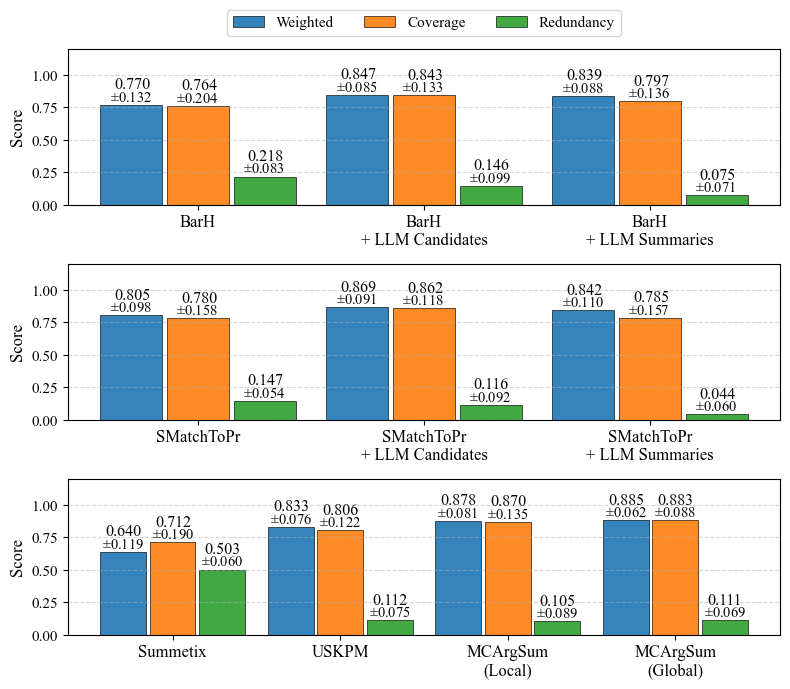

In [35]:
runtime_mean = []
runtime_std = []

c_r = 2 / 3
score_1 = "llm_coverage"
data = "Debate_test"

dir = "investigations/4_automatic_evaluation"
file_names = ["_BarH.json", "_BarH_Candidates.json", "_BarH_Key_Points.json"]
file_names = [data + file_name for file_name in file_names]

x = ["BarH", "BarH\n+ LLM Candidates", "BarH\n+ LLM Summaries"]

cols = ["tab:blue", "tab:orange", "tab:green"]
x_ticks = [
    [0, 2 + 0.2, 4 + 0.4],
    [0.65, 2.65 + 0.2, 4.65 + 0.4],
    [1.3, 3.3 + 0.2, 5.3 + 0.4],
]

plt.figure(figsize=(8, 7))

plt.subplot(3, 1, 1)

llm_weighted_system, llm_coverage_system, llm_redundancy_system, runtime_system = (
    get_best_classification_sum(file_names, dir, c_r=c_r, score_1=score_1)
)
runtime_mean += np.mean(runtime_system, axis=1).tolist()
runtime_std += np.std(runtime_system, axis=1).tolist()

for i in range(0, 3):
    y = np.mean(llm_weighted_system, axis=1)[i]
    std = np.std(llm_weighted_system, axis=1)[i]
    if i == 0:
        bar = plt.bar(
            x=x_ticks[0][i],
            width=0.6,
            height=y,
            color=cols[0],
            edgecolor="black",
            linewidth=0.5,
            alpha=0.9,
            label="Weighted",
        )
    else:
        bar = plt.bar(
            x=x_ticks[0][i],
            width=0.6,
            height=y,
            color=cols[0],
            edgecolor="black",
            linewidth=0.5,
            alpha=0.9,
        )
    plt.text(
        x_ticks[0][i] - 0.155 - 0.01,
        y + 0.11 + 0.01,
        f"{np.round(y, 3)}00"[0:5],
        fontsize=11.5,
    )
    plt.text(
        x_ticks[0][i] - 0.2 - 0.01,
        y + 0.015 + 0.01,
        r"$\pm$" + f"{np.round(std, 3)}00"[0:5],
        fontsize=10.5,
    )

    y = np.mean(llm_coverage_system, axis=1)[i]
    std = np.std(llm_coverage_system, axis=1)[i]
    if i == 0:
        bar = plt.bar(
            x=x_ticks[1][i],
            width=0.6,
            height=y,
            color=cols[1],
            edgecolor="black",
            linewidth=0.5,
            alpha=0.9,
            label="Coverage",
        )
    else:
        bar = plt.bar(
            x=x_ticks[1][i],
            width=0.6,
            height=y,
            color=cols[1],
            edgecolor="black",
            linewidth=0.5,
            alpha=0.9,
        )
    plt.text(
        x_ticks[1][i] - 0.155 - 0.01,
        y + 0.11 + 0.01,
        f"{np.round(y, 3)}00"[0:5],
        fontsize=11.5,
    )
    plt.text(
        x_ticks[1][i] - 0.2 - 0.01,
        y + 0.015 + 0.01,
        r"$\pm$" + f"{np.round(std, 3)}00"[0:5],
        fontsize=10.5,
    )

    y = np.mean(llm_redundancy_system, axis=1)[i]
    std = np.std(llm_redundancy_system, axis=1)[i]
    if i == 0:
        bar = plt.bar(
            x=x_ticks[2][i],
            width=0.6,
            height=y,
            color=cols[2],
            edgecolor="black",
            linewidth=0.5,
            alpha=0.9,
            label="Redundancy",
        )
    else:
        bar = plt.bar(
            x=x_ticks[2][i],
            width=0.6,
            height=y,
            color=cols[2],
            edgecolor="black",
            linewidth=0.5,
            alpha=0.9,
        )
    plt.text(
        x_ticks[2][i] - 0.155 - 0.01,
        y + 0.11 + 0.01,
        f"{np.round(y, 3)}00"[0:5],
        fontsize=11.5,
    )
    plt.text(
        x_ticks[2][i] - 0.2 - 0.01,
        y + 0.015 + 0.01,
        r"$\pm$" + f"{np.round(std, 3)}00"[0:5],
        fontsize=10.5,
    )

plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.xticks(ticks=x_ticks[1], labels=x, fontsize=12)
plt.yticks(fontsize=11)
plt.ylabel("Score", fontsize=12)
plt.ylim(0, 1.2)
plt.legend(
    loc="upper center", bbox_to_anchor=(0.5, 1.3), ncol=3, fontsize=11, fancybox=True
)

plt.subplot(3, 1, 2)

dir = "investigations/4_automatic_evaluation"
file_names = [
    "_SMatchToPr.json",
    "_SMatchToPr_Candidates.json",
    "_SMatchToPr_Key_Points.json",
]
file_names = [data + file_name for file_name in file_names]

x = ["SMatchToPr", "SMatchToPr\n+ LLM Candidates", "SMatchToPr\n+ LLM Summaries"]

cols = ["tab:blue", "tab:orange", "tab:green"]
x_ticks = [
    [0, 2 + 0.2, 4 + 0.4],
    [0.65, 2.65 + 0.2, 4.65 + 0.4],
    [1.3, 3.3 + 0.2, 5.3 + 0.4],
]

llm_weighted_system, llm_coverage_system, llm_redundancy_system, runtime_system = (
    get_best_classification_sum(file_names, dir, c_r=c_r, score_1=score_1)
)
runtime_mean += np.mean(runtime_system, axis=1).tolist()
runtime_std += np.std(runtime_system, axis=1).tolist()

for i in range(0, 3):
    y = np.mean(llm_weighted_system, axis=1)[i]
    std = np.std(llm_weighted_system, axis=1)[i]
    if i == 0:
        bar = plt.bar(
            x=x_ticks[0][i],
            width=0.6,
            height=y,
            color=cols[0],
            edgecolor="black",
            linewidth=0.5,
            alpha=0.9,
            label="Weighted",
        )
    else:
        bar = plt.bar(
            x=x_ticks[0][i],
            width=0.6,
            height=y,
            color=cols[0],
            edgecolor="black",
            linewidth=0.5,
            alpha=0.9,
        )
    plt.text(
        x_ticks[0][i] - 0.155 - 0.01,
        y + 0.11 + 0.01,
        f"{np.round(y, 3)}00"[0:5],
        fontsize=11.5,
    )
    plt.text(
        x_ticks[0][i] - 0.2 - 0.01,
        y + 0.015 + 0.01,
        r"$\pm$" + f"{np.round(std, 3)}00"[0:5],
        fontsize=10.5,
    )

    y = np.mean(llm_coverage_system, axis=1)[i]
    std = np.std(llm_coverage_system, axis=1)[i]
    if i == 0:
        bar = plt.bar(
            x=x_ticks[1][i],
            width=0.6,
            height=y,
            color=cols[1],
            edgecolor="black",
            linewidth=0.5,
            alpha=0.9,
            label="Coverage",
        )
    else:
        bar = plt.bar(
            x=x_ticks[1][i],
            width=0.6,
            height=y,
            color=cols[1],
            edgecolor="black",
            linewidth=0.5,
            alpha=0.9,
        )
    plt.text(
        x_ticks[1][i] - 0.155 - 0.01,
        y + 0.11 + 0.01,
        f"{np.round(y, 3)}00"[0:5],
        fontsize=11.5,
    )
    plt.text(
        x_ticks[1][i] - 0.2 - 0.01,
        y + 0.015 + 0.01,
        r"$\pm$" + f"{np.round(std, 3)}00"[0:5],
        fontsize=10.5,
    )

    y = np.mean(llm_redundancy_system, axis=1)[i]
    std = np.std(llm_redundancy_system, axis=1)[i]
    if i == 0:
        bar = plt.bar(
            x=x_ticks[2][i],
            width=0.6,
            height=y,
            color=cols[2],
            edgecolor="black",
            linewidth=0.5,
            alpha=0.9,
            label="Redundancy",
        )
    else:
        bar = plt.bar(
            x=x_ticks[2][i],
            width=0.6,
            height=y,
            color=cols[2],
            edgecolor="black",
            linewidth=0.5,
            alpha=0.9,
        )
    plt.text(
        x_ticks[2][i] - 0.155 - 0.01,
        y + 0.11 + 0.01,
        f"{np.round(y, 3)}00"[0:5],
        fontsize=11.5,
    )
    plt.text(
        x_ticks[2][i] - 0.2 - 0.01,
        y + 0.015 + 0.01,
        r"$\pm$" + f"{np.round(std, 3)}00"[0:5],
        fontsize=10.5,
    )

plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.xticks(ticks=x_ticks[1], labels=x, fontsize=12)
plt.yticks(fontsize=11)
plt.ylabel("Score", fontsize=12)
plt.ylim(0, 1.2)


plt.subplot(3, 1, 3)
dir = "investigations/4_automatic_evaluation"
file_names = [
    "_Summetix.json",
    "_USKPM.json",
    "_MCArgSum_SBERT_all_mpnet_base_local.json",
    "_MCArgSum_SBERT_all_mpnet_base_global.json",
]
file_names = [data + file_name for file_name in file_names]

x = ["Summetix", "USKPM", "MCArgSum\n(Local)", "MCArgSum\n(Global)"]

cols = ["tab:blue", "tab:orange", "tab:green"]
x_ticks = [
    [0, 2 + 0.2, 4 + 0.4, 6 + 0.6],
    [0.65, 2.65 + 0.2, 4.65 + 0.4, 6.65 + 0.6],
    [1.3, 3.3 + 0.2, 5.3 + 0.4, 7.3 + 0.6],
]

llm_weighted_system, llm_coverage_system, llm_redundancy_system, runtime_system = (
    get_best_classification_sum(file_names, dir, c_r=c_r, score_1=score_1)
)
runtime_mean += np.mean(runtime_system, axis=1).tolist()
runtime_std += np.std(runtime_system, axis=1).tolist()

for i in range(0, 4):
    y = np.mean(llm_weighted_system, axis=1)[i]
    std = np.std(llm_weighted_system, axis=1)[i]
    if i == 0:
        bar = plt.bar(
            x=x_ticks[0][i],
            width=0.6,
            height=y,
            color=cols[0],
            edgecolor="black",
            linewidth=0.5,
            alpha=0.9,
            label="Weighted",
        )
    else:
        bar = plt.bar(
            x=x_ticks[0][i],
            width=0.6,
            height=y,
            color=cols[0],
            edgecolor="black",
            linewidth=0.5,
            alpha=0.9,
        )
    plt.text(
        x_ticks[0][i] - 0.155 - 0.075,
        y + 0.11 + 0.01,
        f"{np.round(y, 3)}00"[0:5],
        fontsize=11.5,
    )
    plt.text(
        x_ticks[0][i] - 0.2 - 0.075,
        y + 0.015 + 0.01,
        r"$\pm$" + f"{np.round(std, 3)}00"[0:5],
        fontsize=10.5,
    )

    y = np.mean(llm_coverage_system, axis=1)[i]
    std = np.std(llm_coverage_system, axis=1)[i]
    if i == 0:
        bar = plt.bar(
            x=x_ticks[1][i],
            width=0.6,
            height=y,
            color=cols[1],
            edgecolor="black",
            linewidth=0.5,
            alpha=0.9,
            label="Coverage",
        )
    else:
        bar = plt.bar(
            x=x_ticks[1][i],
            width=0.6,
            height=y,
            color=cols[1],
            edgecolor="black",
            linewidth=0.5,
            alpha=0.9,
        )
    plt.text(
        x_ticks[1][i] - 0.155 - 0.075,
        y + 0.11 + 0.01,
        f"{np.round(y, 3)}00"[0:5],
        fontsize=11.5,
    )
    plt.text(
        x_ticks[1][i] - 0.2 - 0.075,
        y + 0.015 + 0.01,
        r"$\pm$" + f"{np.round(std, 3)}00"[0:5],
        fontsize=10.5,
    )

    y = np.mean(llm_redundancy_system, axis=1)[i]
    std = np.std(llm_redundancy_system, axis=1)[i]
    if i == 0:
        bar = plt.bar(
            x=x_ticks[2][i],
            width=0.6,
            height=y,
            color=cols[2],
            edgecolor="black",
            linewidth=0.5,
            alpha=0.9,
            label="Redundancy",
        )
    else:
        bar = plt.bar(
            x=x_ticks[2][i],
            width=0.6,
            height=y,
            color=cols[2],
            edgecolor="black",
            linewidth=0.5,
            alpha=0.9,
        )
    plt.text(
        x_ticks[2][i] - 0.155 - 0.075,
        y + 0.11 + 0.01,
        f"{np.round(y, 3)}00"[0:5],
        fontsize=11.5,
    )
    plt.text(
        x_ticks[2][i] - 0.2 - 0.075,
        y + 0.015 + 0.01,
        r"$\pm$" + f"{np.round(std, 3)}00"[0:5],
        fontsize=10.5,
    )

plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.xticks(ticks=x_ticks[1], labels=x, fontsize=12)
plt.yticks(fontsize=11)
plt.ylabel("Score", fontsize=12)
plt.ylim(0, 1.2)


plt.tight_layout()
plt.show()

In [36]:
pd.DataFrame(
    [runtime_mean, runtime_std],
    index=["Runtime", "Std"],
    columns=[
        "BarH",
        "LLM Candidates",
        "LLM Summaries",
        "SMatchToPr",
        "LLM Candidates",
        "LLM Summaries",
        "Summetix",
        "USKPM",
        "MCArgSum (local)",
        "MCArgSum (global)",
    ],
).T.round(3)

,Runtime,Std
BarH,78.772,51.856
LLM Candidates,65.344,27.461
LLM Summaries,14.283,5.804
SMatchToPr,12.531,4.247
LLM Candidates,37.799,8.747
LLM Summaries,15.443,4.455
Summetix,4.015,1.255
USKPM,26.498,17.247
MCArgSum (local),13.709,7.948
MCArgSum (global),7.375,2.553


In [34]:
def calculate_mean_runtime(file_path):
    try:
        with open(file_path, "r", encoding="utf-8") as file:
            data = json.load(file)

        runtimes = []

        for key, value in data.get("summaries", {}).items():
            for topic, opinions in value.items():
                for stance, details in opinions.items():
                    runtime = details.get("runtime")
                    if isinstance(runtime, (int, float)):
                        runtimes.append(runtime)

        if not runtimes:
            print("No runtime values found.")
            return None

        mean_runtime = sum(runtimes) / len(runtimes)
        print(f"Mean Runtime: {mean_runtime:.5f} seconds")
        return mean_runtime
    except Exception as e:
        print(f"Error: {e}")
        return None


def update_scores(runtime_file, scores_file):
    try:
        with open(runtime_file, "r", encoding="utf-8") as file:
            runtime_data = json.load(file)
        with open(scores_file, "r", encoding="utf-8") as file:
            scores_data = json.load(file)

        for key, value in runtime_data.get("summaries", {}).items():
            for topic, opinions in value.items():
                for stance, details in opinions.items():
                    runtime = details.get("runtime")
                    if isinstance(runtime, (int, float)) and topic in scores_data.get(
                        "scores", {}
                    ):
                        if stance in scores_data["scores"][topic]:
                            if key in scores_data["scores"][topic][stance]:
                                scores_data["scores"][topic][stance][key][
                                    "runtime"
                                ] = runtime

        with open(scores_file, "w", encoding="utf-8") as file:
            json.dump(scores_data, file, indent=2)

        print("Scores updated successfully.")
    except Exception as e:
        print(f"Error: {e}")
        return None


runtime_file = "investigations/3_classification_summaries/ArgKP21_SMatchToPr.json"
scores_file = "investigations/4_automatic_evaluation/ArgKP21_SMatchToPr.json"

calculate_mean_runtime(
    "investigations/3_classification_summaries/ArgKP21_SMatchToPr.json"
)
update_scores(runtime_file, scores_file)

Mean Runtime: 17.88459 seconds
Scores updated successfully.


In [12]:
import numpy as np
import pandas as pd


def display_classification_sum_table(
    file_names, labels, directory, c_r=2 / 3, score_1="llm_coverage"
):
    """
    Reads the classification sum data (the same arrays that get plotted)
    and prints a table of Weighted, Coverage, and Redundancy metrics
    for each method in 'labels'.

    file_names:  list of JSON files
    labels:      names to display in the table for each method
    directory:   folder with the classification sum JSON files
    c_r:         coverage ratio or parameter to pass to get_best_classification_sum
    score_1:     which score to treat as the coverage dimension
    """
    # Call the same function you used in the plot code:
    llm_weighted_system, llm_coverage_system, llm_redundancy_system, runtime_system = (
        get_best_classification_sum(file_names, directory, c_r=c_r, score_1=score_1)
    )

    # Prepare rows for a tabular output
    table_rows = []
    for i in range(len(labels)):
        # Weighted
        w_mean = np.mean(llm_weighted_system, axis=1)[i]
        w_std = np.std(llm_weighted_system, axis=1)[i]
        # Coverage
        c_mean = np.mean(llm_coverage_system, axis=1)[i]
        c_std = np.std(llm_coverage_system, axis=1)[i]
        # Redundancy
        r_mean = np.mean(llm_redundancy_system, axis=1)[i]
        r_std = np.std(llm_redundancy_system, axis=1)[i]

        # Construct a row: each cell shows "mean ± std"
        row = [
            labels[i],
            f"{w_mean:.3f} ± {w_std:.3f}",
            f"{c_mean:.3f} ± {c_std:.3f}",
            f"{r_mean:.3f} ± {r_std:.3f}",
        ]
        table_rows.append(row)

    # Convert to a Pandas DataFrame for nice formatting
    df = pd.DataFrame(
        table_rows, columns=["Method", "Weighted", "Coverage", "Redundancy"]
    )
    print(df.to_csv(index=False))  # or just print(df) if you prefer


dir = "investigations/4_automatic_evaluation"
file_prefix = "Debate_test"
file_endings = [
    "_BarH.json",
    "_BarH_Candidates.json",
    "_BarH_Key_Points.json",
    "_SMatchToPr.json",
    "_SMatchToPr_Candidates.json",
    "_SMatchToPr_Key_Points.json",
    "_USKPM.json",
    "_MCArgSum_SBERT_all_mpnet_base_local.json",
    "_MCArgSum_SBERT_all_mpnet_base_global.json",
]
file_names = [file_prefix + file_ending for file_ending in file_endings]

x_labels = [
    "BarH",
    "BarH + LLM Candidates",
    "BarH + LLM Summaries",
    "SMatchToPr",
    "SMatchToPr\n+ LLM Candidates",
    "SMatchToPr\n+ LLM Summaries",
    "USKPM",
    "MCArgSum\n(Local)",
    "MCArgSum\n(Global)",
]
print("-" * 40)
print("Debate_test: ")
print("-" * 40)
display_classification_sum_table(
    file_names, x_labels, directory=dir, c_r=2 / 3, score_1="llm_coverage"
)

file_prefix = "ArgKP21"
file_names = [file_prefix + file_ending for file_ending in file_endings]
print("-" * 40)
print("ArgKP21: ")
print("-" * 40)
display_classification_sum_table(
    file_names, x_labels, directory=dir, c_r=2 / 3, score_1="llm_coverage"
)

----------------------------------------
Debate_test: 
----------------------------------------
Method,Weighted,Coverage,Redundancy
BarH,0.770 ± 0.132,0.764 ± 0.204,0.218 ± 0.083
BarH + LLM Candidates,0.847 ± 0.085,0.843 ± 0.133,0.146 ± 0.099
BarH + LLM Summaries,0.839 ± 0.088,0.797 ± 0.136,0.075 ± 0.071
SMatchToPr,0.805 ± 0.098,0.780 ± 0.158,0.147 ± 0.054
"SMatchToPr
+ LLM Candidates",0.869 ± 0.091,0.862 ± 0.118,0.116 ± 0.092
"SMatchToPr
+ LLM Summaries",0.842 ± 0.110,0.785 ± 0.157,0.044 ± 0.060
USKPM,0.833 ± 0.076,0.806 ± 0.122,0.112 ± 0.075
"MCArgSum
(Local)",0.878 ± 0.081,0.870 ± 0.135,0.105 ± 0.089
"MCArgSum
(Global)",0.885 ± 0.062,0.883 ± 0.088,0.111 ± 0.069

----------------------------------------
ArgKP21: 
----------------------------------------
Method,Weighted,Coverage,Redundancy
BarH,0.848 ± 0.075,0.819 ± 0.122,0.093 ± 0.059
BarH + LLM Candidates,0.877 ± 0.055,0.904 ± 0.058,0.177 ± 0.084
BarH + LLM Summaries,0.859 ± 0.045,0.813 ± 0.080,0.047 ± 0.061
SMatchToPr,0.856 ± 0.037

## Additional Human Evaluation for Debate: Correlation with automatic scores


In [ ]:
df = pd.read_csv("investigations/0_human_evaluation_argkp21/Debate.csv").sort_values(
    ["topic", "stance"]
)

i = 72
plt.figure(figsize=(7, 7))

plt.subplot(2, 2, 1)
plt.scatter(df.human_scores.to_list()[:i], df.coverage_score.to_list()[:i], s=10)
covs_1 = []
for i in range(0, 72, 12):
    covs_1.append(
        np.corrcoef(
            df.human_scores.to_list()[i : i + 12],
            df.coverage_score.to_list()[i : i + 12],
        )[0][1]
    )
plt.title(
    f"{np.round(np.corrcoef(df.human_scores.to_list()[:i], df.coverage_score.to_list()[:i])[0][1],3)} / {np.round(np.mean(covs_1),3)} ($\pm${np.round(np.std(covs_1),3)})",
    fontsize=14,
)
plt.xlim(-0.1, 1.1)
plt.ylim(-0.1, 1.1)
plt.xticks(ticks=[i for i in np.arange(0, 1.1, 0.2)], fontsize=12)
plt.yticks(ticks=[i for i in np.arange(0, 1.1, 0.2)], fontsize=12)
plt.xlabel("Human Coverage Score", fontsize=14)
plt.ylabel("CS (BarH)", fontsize=14)
plt.grid(linestyle="--", alpha=0.5)


plt.subplot(2, 2, 2)
plt.scatter(df.human_scores.to_list()[:i], df.llm_coverage.to_list()[:i], s=10)
covs_1 = []
for i in range(0, 72, 12):
    covs_1.append(
        np.corrcoef(
            df.human_scores.to_list()[i : i + 12], df.llm_coverage.to_list()[i : i + 12]
        )[0][1]
    )
plt.title(
    f"{np.round(np.corrcoef(df.human_scores.to_list()[:i], df.llm_coverage.to_list()[:i])[0][1],3)}0 / {np.round(np.mean(covs_1),3)} ($\pm${np.round(np.std(covs_1),3)})",
    fontsize=14,
)
plt.xticks(ticks=[i for i in np.arange(0, 1.1, 0.2)], fontsize=12)
plt.yticks(ticks=[i for i in np.arange(0, 1.1, 0.2)], fontsize=12)
plt.xlim(-0.1, 1.1)
plt.ylim(-0.1, 1.1)
plt.xlabel("Human Coverage Score", fontsize=14)
plt.ylabel("LLM-based Coverage Score", fontsize=14)
plt.grid(linestyle="--", alpha=0.5)

plt.subplot(2, 2, 3)
plt.scatter(df.human_scores.to_list()[:i], df.bert_score_p.to_list()[:i], s=10)
covs_1 = []
for i in range(0, 72, 12):
    covs_1.append(
        np.corrcoef(
            df.human_scores.to_list()[i : i + 12], df.bert_score_p.to_list()[i : i + 12]
        )[0][1]
    )
plt.title(
    f"{np.round(np.corrcoef(df.human_scores.to_list()[:i], df.bert_score_p.to_list()[:i])[0][1],3)} / {np.round(np.mean(covs_1),3)} ($\pm${np.round(np.std(covs_1),3)})",
    fontsize=14,
)
plt.xlim(-0.1, 1.1)
plt.ylim(-0.1, 1.1)
plt.xticks(ticks=[i for i in np.arange(0, 1.1, 0.2)], fontsize=12)
plt.yticks(ticks=[i for i in np.arange(0, 1.1, 0.2)], fontsize=12)
plt.grid(linestyle="--", alpha=0.5)
plt.xlabel("Human Coverage Score", fontsize=14)
plt.ylabel("sR (BERTScore Precision)", fontsize=14)


plt.tight_layout()

plt.show()